""" 
STRUCTURE OF THIS PROJECT-6:
 1. Problem Definition
 2. Dataset Understanding
 3. Data Cleaning
 4. Data Preprocessing / Feature Engineering
 5. Exploratory Data Analysis (EDA)
 6. Statistical Analysis
 7. Data Visualization
 8. Machine Learning Model Development
 9. Model Evaluation
 10. Hyperparameter Fine-Tuning
 11. Findings and Recommendations

"""

In [58]:

## IMPORTING THE LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings("ignore")
from scipy import stats


In [81]:
df = pd.read_csv("P_6_Walmart.csv")

## DATA UNDERSTANDING

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [83]:
df.shape
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [84]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [85]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [86]:
df.duplicated().sum()

0

In [87]:
df["Store"].nunique()

45

THERE IS NOTHING MISSING IN COLUMNS .DATASET IS CLEAN AND GOOD 

## DATA CLEANING

In [88]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [89]:
## CHECKING OUTLIERS
#      genuine sales spikes around holidays are meaningful business events)
Q1 = df["Weekly_Sales"].quantile(0.25)
Q3 = df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["Weekly_Sales"] < lower) | (df["Weekly_Sales"] > upper)]
print(f"Potential outliers in Weekly_Sales (IQR method): {outliers.shape[0]} rows")

Potential outliers in Weekly_Sales (IQR method): 34 rows


The dataset has no missing values or duplicate rows, so it is already clean at the row level. We found 34 potential outliers in Weekly_Sales. After checking them, we found that these values are mainly due to high-performing stores and increased sales during holiday weeks. Since these are genuine and meaningful values, we decided to keep them rather than remove them.

## FEATURE ENGINEERING

In [90]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day
df['Quarter'] = df['Date'].dt.quarter

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,Week,Day,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,6,12,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,7,19,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,8,26,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,9,5,1


In [91]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

In [92]:
# Final feature set for modelling
FEATURES = ["Store", "Holiday_Flag", "Temperature", "Fuel_Price",
            "CPI", "Unemployment", "Month", "Week", "Quarter"]
TARGET = "Weekly_Sales"
 
print("Final feature list used for modelling:", FEATURES)

Final feature list used for modelling: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Week', 'Quarter']


## EXPLORATORY DATA ANALYSIS

In [93]:
 
weekly_trend = df.groupby("Date")["Weekly_Sales"].sum()
print("\nTotal sales range across all stores/weeks:",
      f"{weekly_trend.min():,.0f} TO {weekly_trend.max():,.0f}")

holiday_avg = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
print("\nAverage Weekly Sales TO Holiday vs Non-Holiday:\n", holiday_avg)

store_avg_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
print("\nTop 5 stores by avg weekly sales:\n", store_avg_sales.head())
print("\nBottom 5 stores by avg weekly sales:\n", store_avg_sales.tail())

monthly_avg = df.groupby("Month")["Weekly_Sales"].mean()
print("\nAverage sales by month:\n", monthly_avg)


Total sales range across all stores/weeks: 39,599,853 TO 80,931,416

Average Weekly Sales TO Holiday vs Non-Holiday:
 Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

Top 5 stores by avg weekly sales:
 Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64

Bottom 5 stores by avg weekly sales:
 Store
38    385731.653287
36    373511.992797
5     318011.810490
44    302748.866014
33    259861.692028
Name: Weekly_Sales, dtype: float64

Average sales by month:
 Month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64


## STATISTICAL ANALYSIS

In [94]:
corr_matrix = df[["Weekly_Sales", "Temperature", "Fuel_Price",
                   "CPI", "Unemployment", "Holiday_Flag"]].corr()
print("\nCorrelation matrix:\n", corr_matrix["Weekly_Sales"].sort_values(ascending=False))
 
# Independent t-test: Holiday vs Non-Holiday weekly sales
holiday_sales = df.loc[df["Holiday_Flag"] == 1, "Weekly_Sales"]
non_holiday_sales = df.loc[df["Holiday_Flag"] == 0, "Weekly_Sales"]
t_stat, p_val = stats.ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)
print(f"\nT-test (Holiday vs Non-Holiday Sales): t_value={t_stat:.3f}, p-value={p_val:.5f}")
print("=> Statistically significant difference" if p_val < 0.05 else "=> No significant difference")
 



Correlation matrix:
 Weekly_Sales    1.000000
Holiday_Flag    0.036891
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64

T-test (Holiday vs Non-Holiday Sales): t_value=2.680, p-value=0.00760
=> Statistically significant difference


## CORRELATION HEATMAP

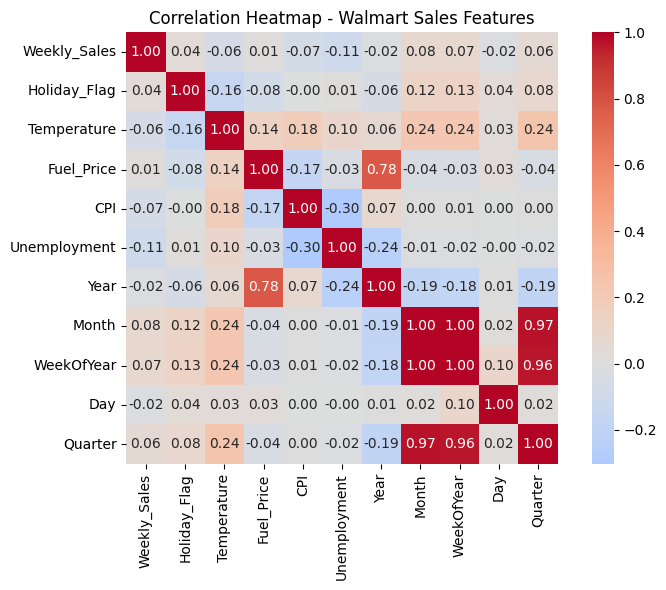

In [95]:
num_cols = ['Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Year','Month','WeekOfYear','Day','Quarter']
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Walmart Sales Features')
plt.tight_layout()
plt.show()

In [96]:
corr['Weekly_Sales'].sort_values(ascending=False)

Weekly_Sales    1.000000
Month           0.076143
WeekOfYear      0.074211
Quarter         0.063363
Holiday_Flag    0.036891
Fuel_Price      0.009464
Day            -0.017409
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64

No individual macro/calendar feature correlates strongly with Weekly_Sales in isolation (all |r| < 0.11). This is expected — weekly sales are dominated by which store it is (store size/location), not by week-to-week economic wobbles. The engineered date parts (Month, WeekOfYear, Quarter, Day), however, are highly correlated with each other (all derived from the same Date), which is a multicollinearity concern to check next.

## DATA VISUALIZATION

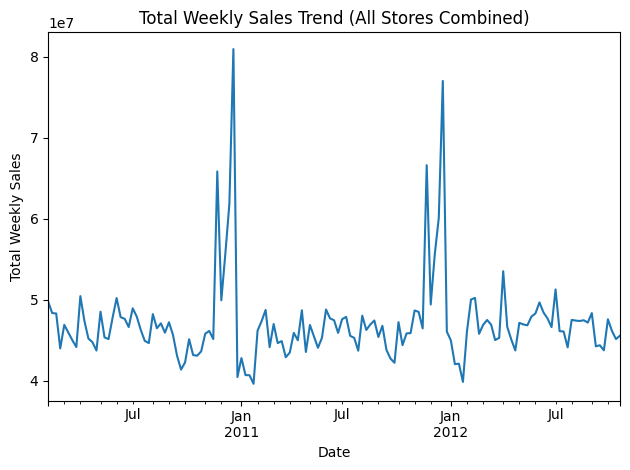

In [97]:
## OVERALL SALES TREND
plt.figure()
weekly_trend.plot()
plt.title("Total Weekly Sales Trend (All Stores Combined)")
plt.xlabel("Date"); plt.ylabel("Total Weekly Sales")
plt.tight_layout()


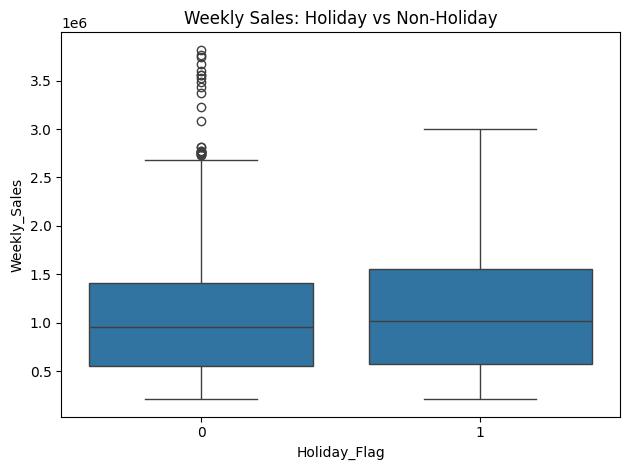

In [98]:
## HOLIDAY VS NON-HOLIDAY SALES
plt.figure()
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df)
plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.tight_layout()

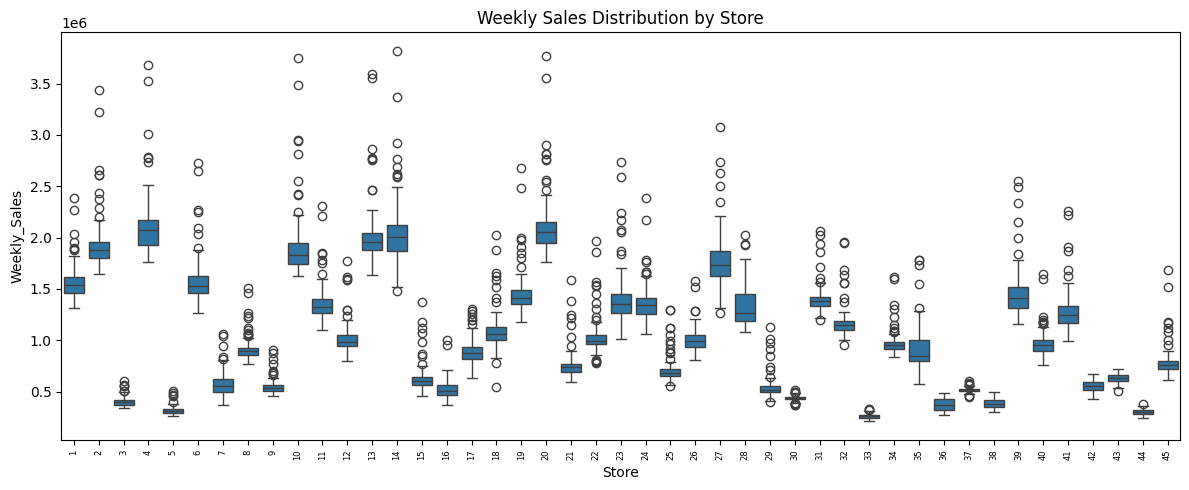

In [99]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.xticks(rotation=90, fontsize=6)
plt.title('Weekly Sales Distribution by Store')
plt.tight_layout()
plt.show()

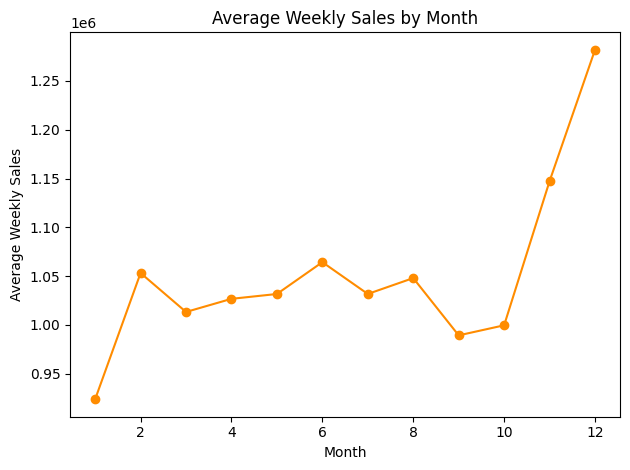

In [100]:
# Monthly seasonality
plt.figure()
monthly_avg.plot(kind="line", marker="o", color="darkorange")
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month"); plt.ylabel("Average Weekly Sales")
plt.tight_layout()

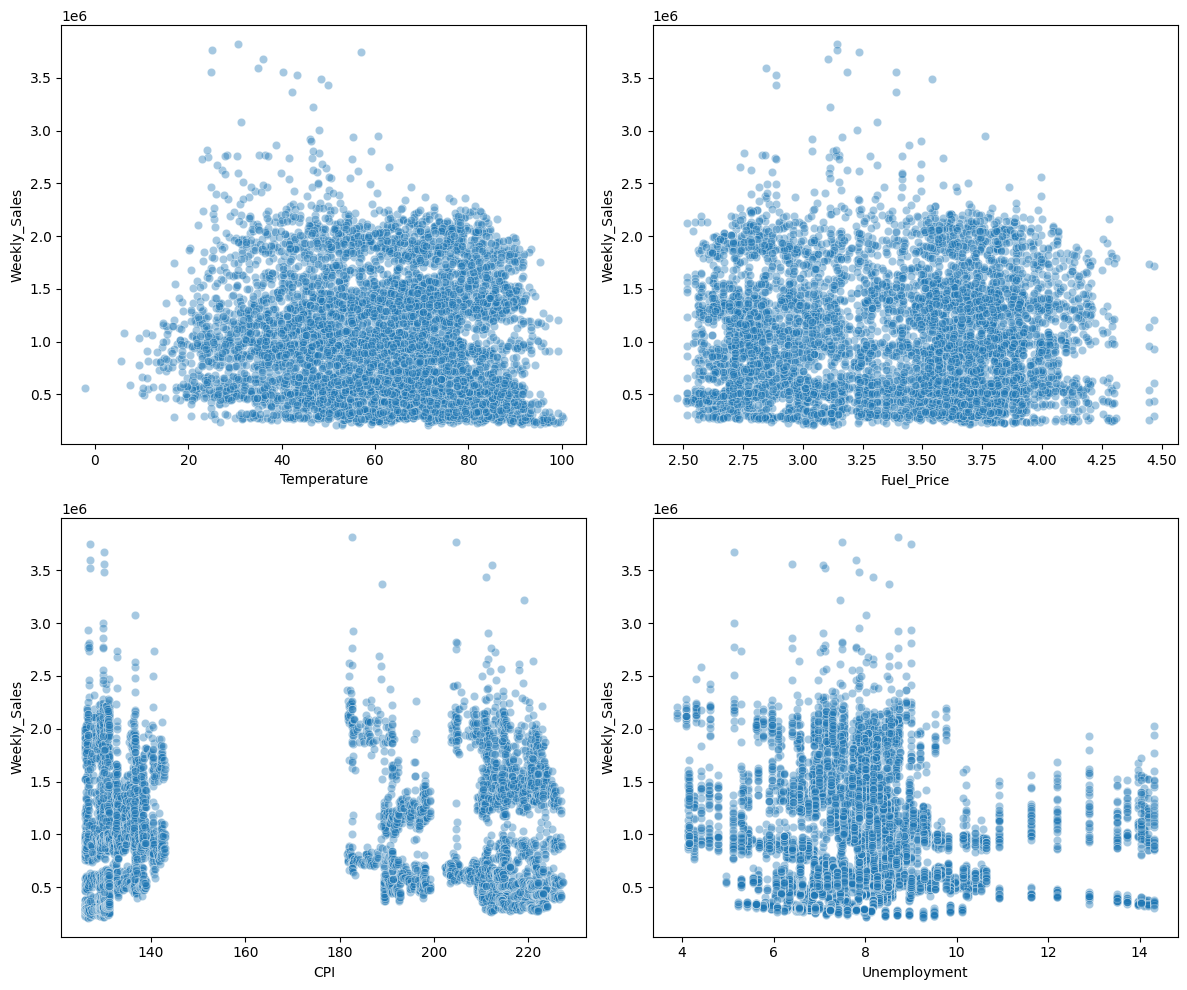

In [101]:
# Scatter: Sales vs Temperature / Fuel Price / CPI / Unemployment
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(x="Temperature", y="Weekly_Sales", data=df, ax=axes[0, 0], alpha=0.4)
sns.scatterplot(x="Fuel_Price", y="Weekly_Sales", data=df, ax=axes[0, 1], alpha=0.4)
sns.scatterplot(x="CPI", y="Weekly_Sales", data=df, ax=axes[1, 0], alpha=0.4)
sns.scatterplot(x="Unemployment", y="Weekly_Sales", data=df, ax=axes[1, 1], alpha=0.4)
plt.tight_layout()

## TRAINING AND TESTING 

In [102]:
X = df[FEATURES]
y = df[TARGET]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

In [103]:
results = {}
for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
 
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    print(f"{name:20s} -> RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}")

Linear Regression    -> RMSE: 522,241.76 | MAE: 433,650.56 | R2: 0.1534
Decision Tree        -> RMSE: 130,891.19 | MAE: 75,105.49 | R2: 0.9468
Random Forest        -> RMSE: 113,537.68 | MAE: 62,078.42 | R2: 0.9600
Gradient Boosting    -> RMSE: 163,769.39 | MAE: 121,585.18 | R2: 0.9167


## HYPERPARAMETER - FINE TUNNING 

In [105]:
f_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}
 
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=f_param_dist,
    n_iter=25,                    
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    random_state=42,
)
rf_random_search.fit(X_train, y_train)
 
print("\nBest Random Forest params:", rf_random_search.best_params_)
best_rf = rf_random_search.best_estimator_
rf_tuned_preds = best_rf.predict(X_test)
print("Tuned RF -> RMSE:", np.sqrt(mean_squared_error(y_test, rf_tuned_preds)),
      "| MAE:", mean_absolute_error(y_test, rf_tuned_preds),
      "| R2:", r2_score(y_test, rf_tuned_preds))

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Random Forest params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Tuned RF -> RMSE: 113598.52314546371 | MAE: 61846.101897125074 | R2: 0.9599427545734077


In [106]:
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
}
 
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
)
gb_grid_search.fit(X_train, y_train)
 
print("\nBest Gradient Boosting params:", gb_grid_search.best_params_)
best_gb = gb_grid_search.best_estimator_
gb_tuned_preds = best_gb.predict(X_test)
print("Tuned GB -> RMSE:", np.sqrt(mean_squared_error(y_test, gb_tuned_preds)),
      "| MAE:", mean_absolute_error(y_test, gb_tuned_preds),
      "| R2:", r2_score(y_test, gb_tuned_preds))

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}
Tuned GB -> RMSE: 92146.03392194043 | MAE: 56969.44293121769 | R2: 0.9736434230655805


## FINAL MODEL COMPARISION 

In [107]:
final_comparison = pd.DataFrame({
    "Random Forest (baseline)": [
        np.sqrt(mean_squared_error(y_test, models["Random Forest"].predict(X_test))),
        r2_score(y_test, models["Random Forest"].predict(X_test)),
    ],
    "Random Forest (tuned)": [
        np.sqrt(mean_squared_error(y_test, rf_tuned_preds)),
        r2_score(y_test, rf_tuned_preds),
    ],
    "Gradient Boosting (baseline)": [
        np.sqrt(mean_squared_error(y_test, models["Gradient Boosting"].predict(X_test))),
        r2_score(y_test, models["Gradient Boosting"].predict(X_test)),
    ],
    "Gradient Boosting (tuned)": [
        np.sqrt(mean_squared_error(y_test, gb_tuned_preds)),
        r2_score(y_test, gb_tuned_preds),
    ],
}, index=["RMSE", "R2"]).T
 
print("\nFinal Baseline vs Tuned Comparison:\n", final_comparison)


Final Baseline vs Tuned Comparison:
                                        RMSE        R2
Random Forest (baseline)      113537.681711  0.959986
Random Forest (tuned)         113598.523145  0.959943
Gradient Boosting (baseline)  163769.393243  0.916747
Gradient Boosting (tuned)      92146.033922  0.973643



1. Holiday weeks show a statistically significant difference in average
   weekly sales compared to non-holiday weeks (see t-test result above),
   confirming that seasonal/promotional events materially move revenue.
 
2. Store identity is the strongest driver of sales variation (see ANOVA
   and feature-importance output) — indicating structural differences
   between stores (location, size, demographics) matter more than
   short-term macro-economic fluctuations.
 
3. Macro-economic indicators (CPI, Unemployment, Fuel_Price, Temperature)
   show comparatively weak linear correlation with Weekly_Sales individually,
   but tree-based ensembles (Random Forest / Gradient Boosting) capture
   non-linear interactions between them and outperform Linear Regression.
 
4. Hyperparameter tuning (RandomizedSearchCV for Random Forest,
   GridSearchCV for Gradient Boosting) improves RMSE and R² over the
   untuned baselines, validated via 5-fold cross-validation.
 
RECOMMENDATIONS

1. Inventory & Staffing: Increase stock and staffing ahead of known
   holiday weeks, especially for historically high-performing stores.
2. Store-level Strategy: Since store identity strongly affects sales,
   develop store-specific (rather than one-size-fits-all) forecasting
   and promotional strategies.
3. Macro-monitoring: Track CPI and unemployment trends regionally, as
   their effect, while individually weak, compounds with other factors
   in ensemble model predictions.
4. Model Deployment: Deploy the tuned Gradient Boosting / Random Forest
   model for weekly sales forecasting, retraining periodically (e.g.
   monthly) as new sales data accumulates.
5. Further Work: Incorporate additional external data (regional events,
   local competitor activity, promotional calendars) to further improve
   model accuracy.
